# Descriptive Analysis: Evaluation Dataset

**Dataset:** Wikinews Text-Continuation, Model: Qwen-2  
**Methods:** `beam(5)`, `CS(('0.6','10'))`, `Human`, `temp(0.9)`, `topk(50)`, `topp(0.95)`  
**Evaluations:** 
- Human_Evaluation_A/B on scale from 1-5 (bad to good)
- Perplexity: how well a model can predict a sample
- Coherence: semantic consistency
- Diversity: lexical or semantic diversity
- Q_Text: metric from Paper https://aclanthology.org/2025.gem-1.59/

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import openpyxl

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Style settings for plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Color palette per method
METHOD_COLORS = {
    'Human':          '#2ecc71',
    'beam (5)':       '#3498db',
    "CS (('0.6', '10'))": '#9b59b6',
    'temp (0.9)':     '#e67e22',
    'topk (50)':      '#e74c3c',
    'topp (0.95)':    '#1abc9c',
}

## Load & Prepare Data

In [4]:
DATA_PATH = 'data/human_evaluation_scores.xlsx'

df = pd.read_excel(DATA_PATH)

# Normalize column names (remove whitespace)
df.columns = df.columns.str.strip()

# Mean Human Evaluation
df['Human_Eval_Mean'] = df[['Human_Evaluation_A', 'Human_Evaluation_B']].mean(axis=1)

print(f'Shape: {df.shape}')
print(f'Methods: {df["Method"].unique()}')
print(f'Datasets: {df["ID_Dataset"].nunique()} unique prompts')
df.head(6)

Shape: (300, 11)
Methods: <ArrowStringArray>
[         'topk (50)', 'CS (('0.6', '10'))',           'beam (5)',
              'Human',         'temp (0.9)',        'topp (0.95)']
Length: 6, dtype: str
Datasets: 50 unique prompts


,ID_Dataset,Model,Method,Samples,Human_Evaluation_A,Human_Evaluation_B,Perplexity,Coherence,Diversity,Q_Text,Human_Eval_Mean
0,548 wikitext,Qwen 2,topk (50),"Prompt: <|endoftext|> A total of 2 @,@ 000 peo...",4,3,22.497418,95.967886,98.05,46.105205,3.5
1,755 wikitext,Qwen 2,topk (50),Prompt: <|endoftext|> The United Kingdom posse...,5,4,14.745025,88.807264,98.08,33.603813,4.5
2,1292 wikinews,Qwen 2,"CS (('0.6', '10'))",Prompt: Astronomers have discovered a planetar...,3,3,8.068517,50.868037,96.07,19.479723,3.0
3,345 wikinews,Qwen 2,beam (5),Prompt: A man has died after being involved in...,1,2,1.966307,95.039801,4.33,3.999806,1.5
4,693 wikitext,Human,Human,Prompt: <|endoftext|> The 1933 Treasure Coast ...,4,4,17.743817,66.814620,92.28,36.513663,4.0
5,1179 wikitext,Human,Human,Prompt: <|endoftext|> Derry City lies near the...,4,4,24.815349,61.430213,97.56,44.892453,4.0


## Overview: Summary Statistics

In [9]:
METRICS = ['Human_Evaluation_A', 'Human_Evaluation_B', 'Human_Eval_Mean', 'Perplexity', 'Coherence', 'Diversity', 'Q_Text']

# Overall
print('Overall:')
display(df[METRICS].describe().round(2))

# Per method
print('\nPer Method:')
display(df.groupby('Method')[METRICS].mean().round(2))

Overall:


,Human_Evaluation_A,Human_Evaluation_B,Human_Eval_Mean,Perplexity,Coherence,Diversity,Q_Text
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,2.38,2.69,2.54,16.48,75.88,80.38,30.77
std,1.22,0.85,0.90,13.92,13.80,28.04,17.19
min,1.00,1.00,1.00,1.20,7.13,0.08,0.23
25%,1.00,2.00,2.00,7.56,66.25,79.82,18.68
50%,2.00,3.00,2.50,13.40,78.47,92.94,30.54
75%,3.00,3.00,3.00,20.68,86.56,97.31,42.24
max,5.00,5.00,4.50,85.31,98.39,100.00,89.80



Per Method:


,Human_Evaluation_A,Human_Evaluation_B,Human_Eval_Mean,Perplexity,Coherence,Diversity,Q_Text
Method,,,,,,,
"CS (('0.6', '10'))",2.18,2.42,2.30,11.26,60.20,90.67,23.60
Human,3.08,3.44,3.26,31.36,62.15,93.27,47.95
beam (5),1.64,2.36,2.00,3.06,88.16,34.67,7.02
temp (0.9),2.24,2.60,2.42,20.46,86.22,88.57,38.66
topk (50),2.46,2.62,2.54,16.99,80.68,87.32,35.06
topp (0.95),2.70,2.68,2.69,15.78,77.87,87.80,32.33


## Distributions: Human Evaluations per Method

/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_68934/838342608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_68934/838342608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


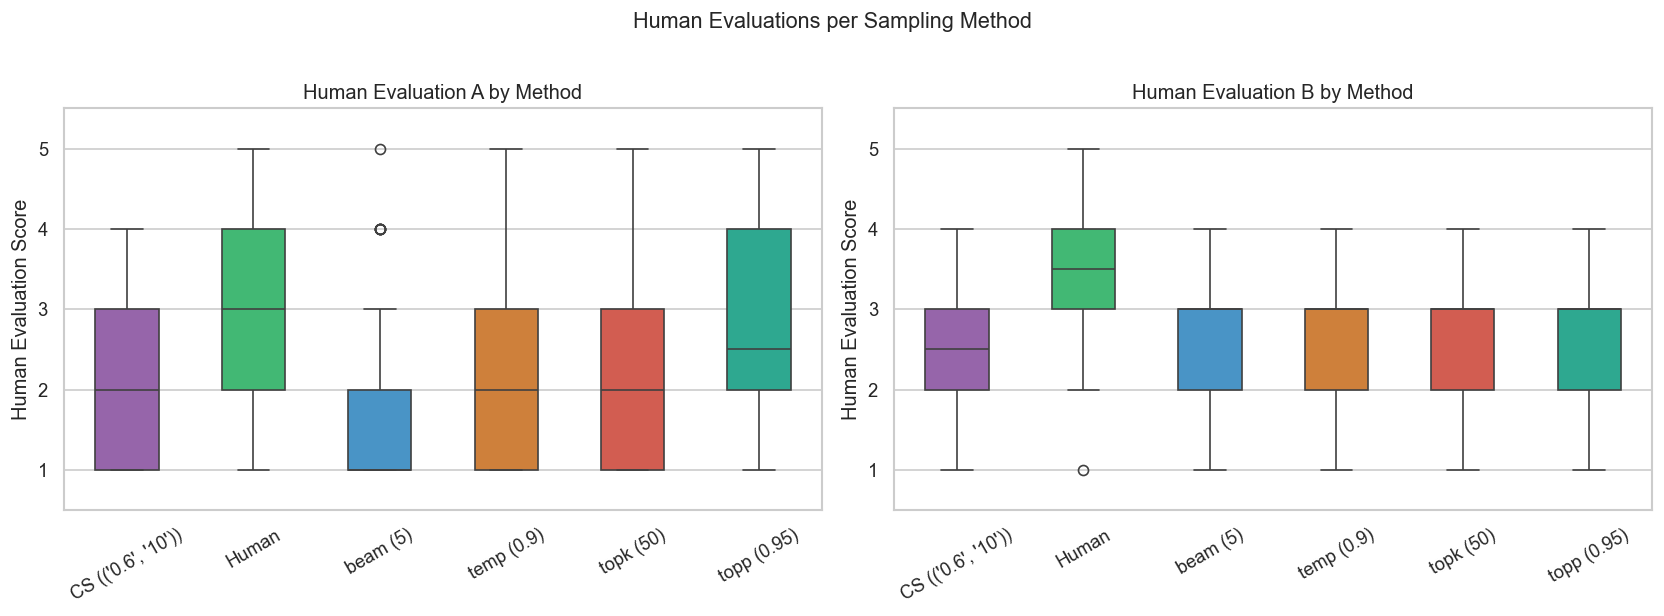

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Human_Evaluation_A', 'Human_Evaluation_B']):
    sns.boxplot(
        data=df, x='Method', y=col,
        palette=METHOD_COLORS, order=sorted(df['Method'].unique()),
        ax=ax, width=0.5
    )
    ax.set_xlabel('')
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(f'{col.replace("_", " ")} by Method', fontsize=12)
    ax.set_ylabel('Human Evaluation Score')

plt.suptitle('Human Evaluations per Sampling Method', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('figures/data_description/human_eval_per_method.png', bbox_inches='tight')
plt.show()

## Metrics per Method

/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_68934/3723472180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


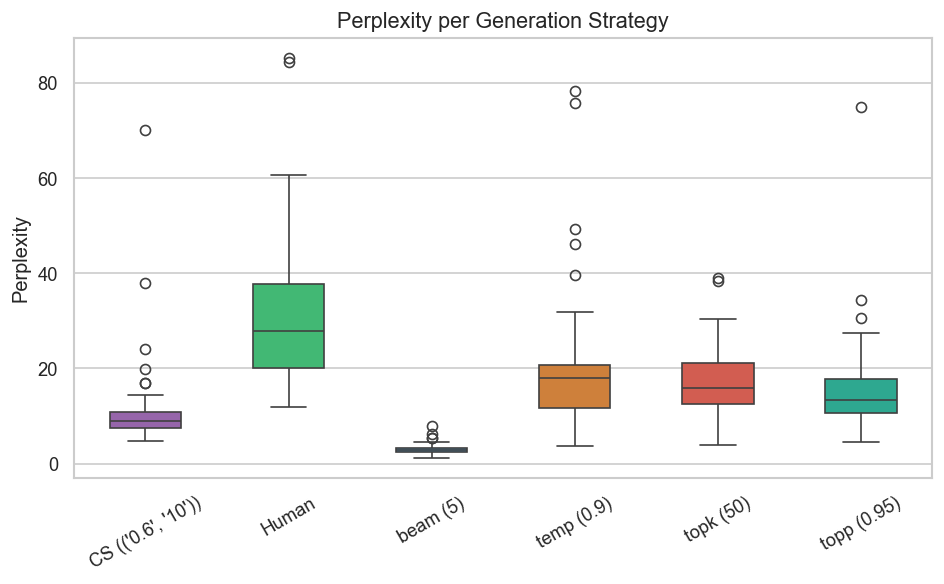

/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_68934/3723472180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


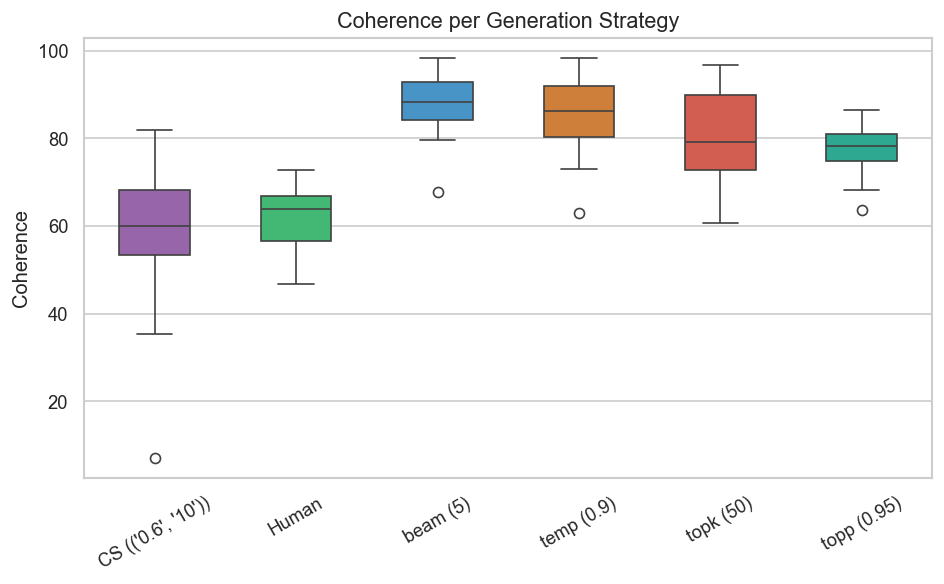

/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_68934/3723472180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


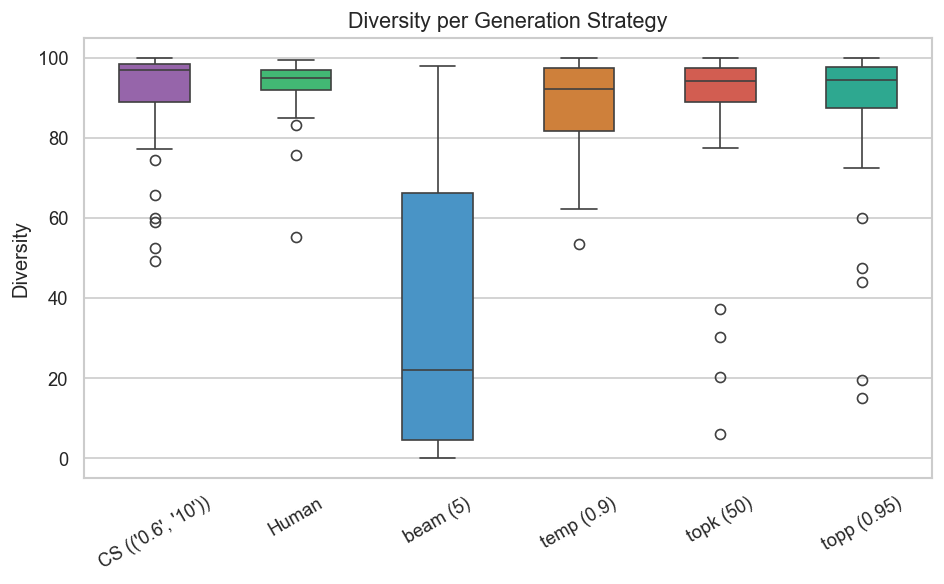

/var/folders/8p/gf18y7cn497_l5dv5x3gp0q40000gp/T/ipykernel_68934/3723472180.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


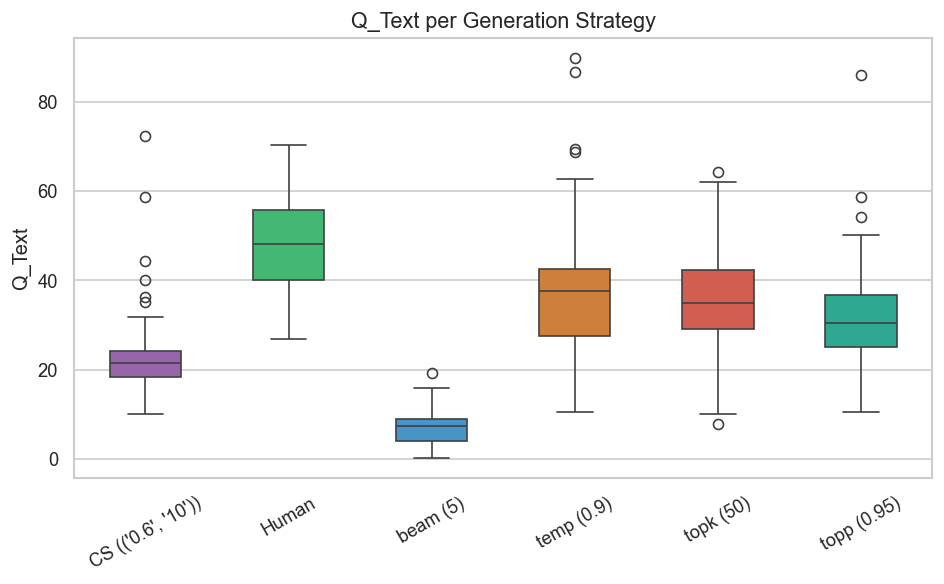

Means per Method:


,Perplexity,Coherence,Diversity,Q_Text
Method,,,,
"CS (('0.6', '10'))",11.26,60.20,90.67,23.60
Human,31.36,62.15,93.27,47.95
beam (5),3.06,88.16,34.67,7.02
temp (0.9),20.46,86.22,88.57,38.66
topk (50),16.99,80.68,87.32,35.06
topp (0.95),15.78,77.87,87.80,32.33


In [21]:
AUTO_METRICS = ['Perplexity', 'Coherence', 'Diversity', 'Q_Text']

for metric in AUTO_METRICS:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=df, x='Method', y=metric,
        palette=METHOD_COLORS, order=sorted(df['Method'].unique()),
        ax=ax, width=0.5
    )
    ax.set_title(f'{metric} per Generation Strategy', fontsize=13)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'figures/data_description/human_eval_metric_{metric.lower()}_per_method.png', bbox_inches='tight')
    plt.show()

# Table: means per method for all automatic metrics
print('Means per Method:')
display(df.groupby('Method')[AUTO_METRICS].mean().round(2))

## Inter-Annotator Agreement (Cohen's Kappa)

Cohen's Kappa (ungewichtet):      0.175
Cohen's Kappa (quadr. gewichtet): 0.466
Spearman Korrelation:              0.529  (p=0.0000)

Interpretation Kappa: <0.2 schlecht | 0.2-0.4 fair | 0.4-0.6 moderat | 0.6-0.8 gut | >0.8 sehr gut


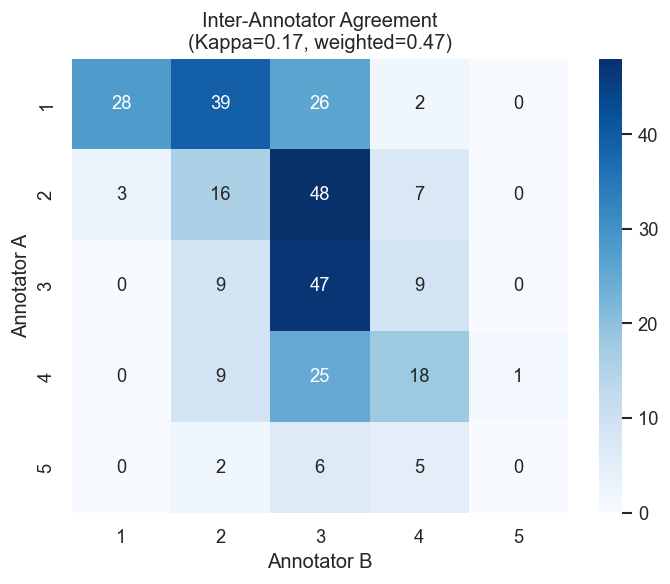

In [22]:
from sklearn.metrics import cohen_kappa_score

# Only consider rows where both annotators have a score
df_annot = df[['Human_Evaluation_A', 'Human_Evaluation_B']].dropna()
df_annot = df_annot.astype(int)

# Cohen's Kappa (unweighted and weighted by quadratic weights)
kappa = cohen_kappa_score(df_annot['Human_Evaluation_A'], df_annot['Human_Evaluation_B'])
kappa_w = cohen_kappa_score(df_annot['Human_Evaluation_A'], df_annot['Human_Evaluation_B'],
                             weights='quadratic')

# Spearman-Korrelation between both annotators
corr_spearman, p_val = stats.spearmanr(
    df_annot['Human_Evaluation_A'], df_annot['Human_Evaluation_B']
)

print(f'Cohen\'s Kappa (ungewichtet):      {kappa:.3f}')
print(f'Cohen\'s Kappa (quadr. gewichtet): {kappa_w:.3f}')
print(f'Spearman Korrelation:              {corr_spearman:.3f}  (p={p_val:.4f})')
print()
print('Interpretation Kappa: <0.2 schlecht | 0.2-0.4 fair | 0.4-0.6 moderat | 0.6-0.8 gut | >0.8 sehr gut')

# Agreement heatmap (absolute counts)
agreement = pd.crosstab(
    df_annot['Human_Evaluation_A'],
    df_annot['Human_Evaluation_B'],
    rownames=['Annotator A'], colnames=['Annotator B']
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agreement, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Inter-Annotator Agreement\n(Kappa={kappa:.2f}, weighted={kappa_w:.2f})')
plt.tight_layout()
plt.savefig('figures/data_description/human_eval_inter_annotator_agreement.png', bbox_inches='tight')
plt.show()

## Correlation between annotators and metrics

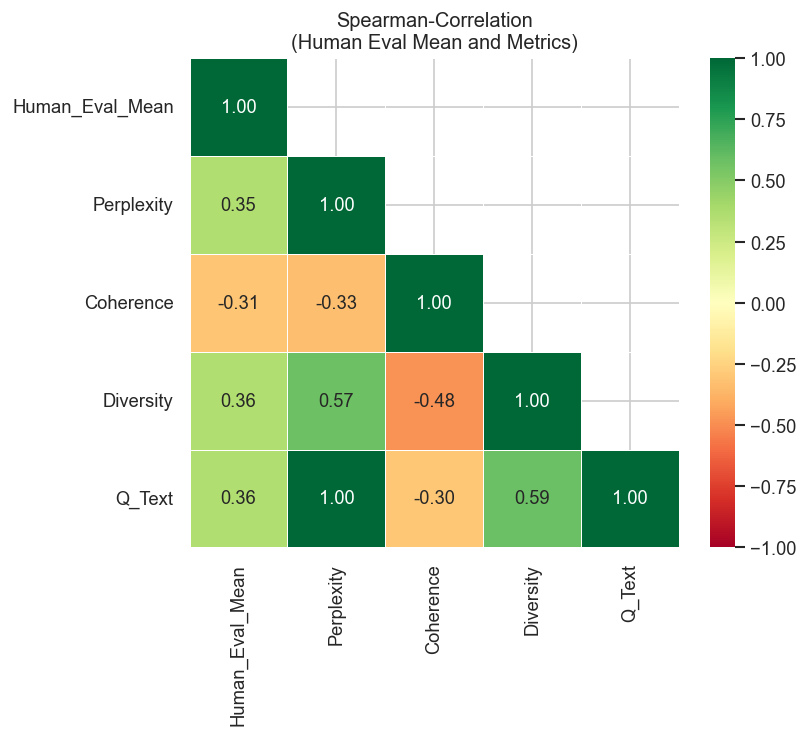


Korrelationen mit Human_Eval_Mean:
Q_Text        0.357
Diversity     0.356
Perplexity    0.353
Coherence    -0.307
Name: Human_Eval_Mean, dtype: float64


In [24]:
# Spearman-Korrelation
corr_cols = ['Human_Eval_Mean', 'Perplexity', 'Coherence', 'Diversity', 'Q_Text']
corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # oberes Dreieck ausblenden

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, mask=mask, ax=ax,
    linewidths=0.5, square=True
)
ax.set_title('Spearman-Correlation\n(Human Eval Mean and Metrics)')
plt.tight_layout()
plt.savefig('figures/data_description/human_eval_spearman_correlations.png', bbox_inches='tight')
plt.show()

# Tabel: only human eval mean as target variable
print('\nKorrelationen mit Human_Eval_Mean:')
corr_target = df[corr_cols].corr(method='spearman')['Human_Eval_Mean'].drop('Human_Eval_Mean')
print(corr_target.sort_values(ascending=False).round(3))

## Human vs. Model

Durchschnittswerte Human vs. Modell:


,Perplexity,Coherence,Diversity,Q_Text,Human_Eval_Mean
Modell (alle),13.51,78.63,77.81,27.33,2.39
Human,31.36,62.15,93.27,47.95,3.26


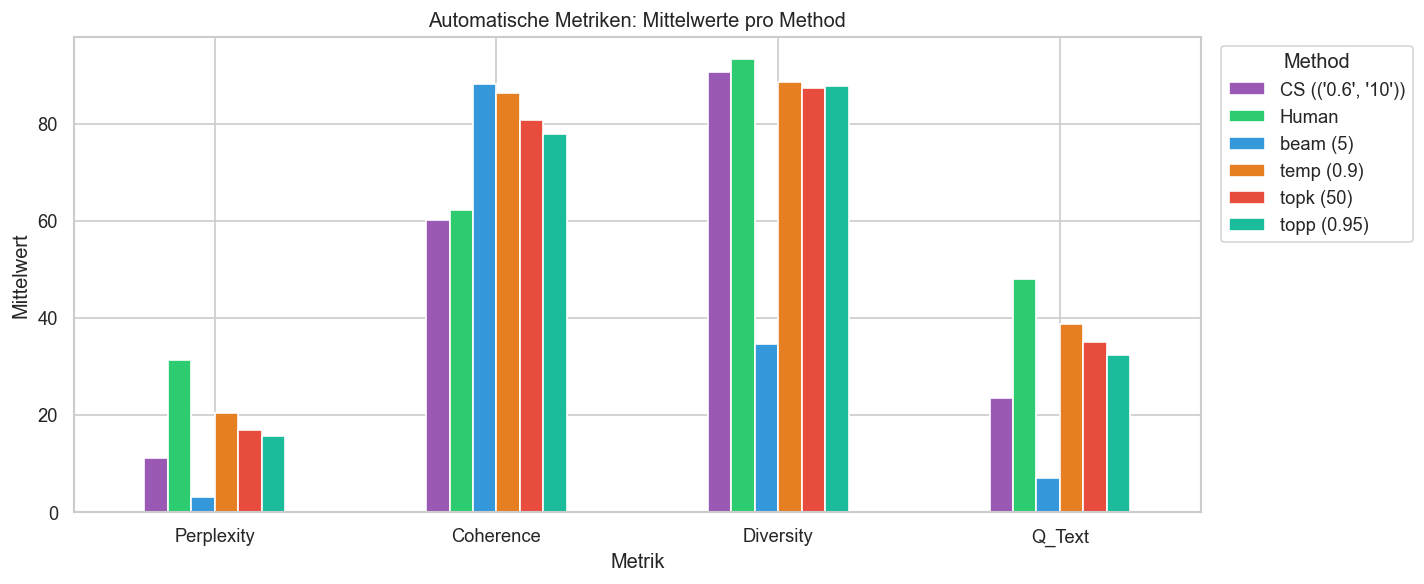

In [25]:
# Means per method for all automatic metrics + human eval mean
df['Is_Human'] = df['Method'] == 'Human'

summary = df.groupby('Is_Human')[AUTO_METRICS + ['Human_Eval_Mean']].mean().round(2)
summary.index = ['Modell (alle)', 'Human']
print('Durchschnittswerte Human vs. Modell:')
display(summary)

# Barplot: Means per method for all metrics + human eval mean
method_means = df.groupby('Method')[AUTO_METRICS + ['Human_Eval_Mean']].mean()

fig, ax = plt.subplots(figsize=(12, 5))
method_means[AUTO_METRICS].T.plot(kind='bar', ax=ax,
                                   color=[METHOD_COLORS.get(m, '#999') for m in method_means.index])
ax.set_title('Automatische Metriken: Mittelwerte pro Method')
ax.set_xlabel('Metrik')
ax.set_ylabel('Mittelwert')
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('figures/data_description/human_eval_method_comparison_bar.png', bbox_inches='tight')
plt.show()